# MISOCP 电力系统复现

6 节点径向配电网：1 个变电站节点，5 个负荷节点，5 条支路。第二个代码 cell 使用 Gurobi 建立并求解 MILP 最优潮流调度。

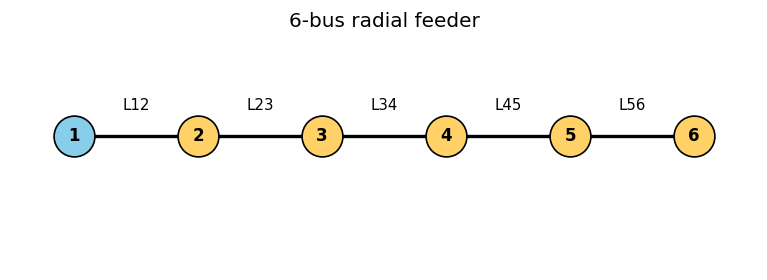

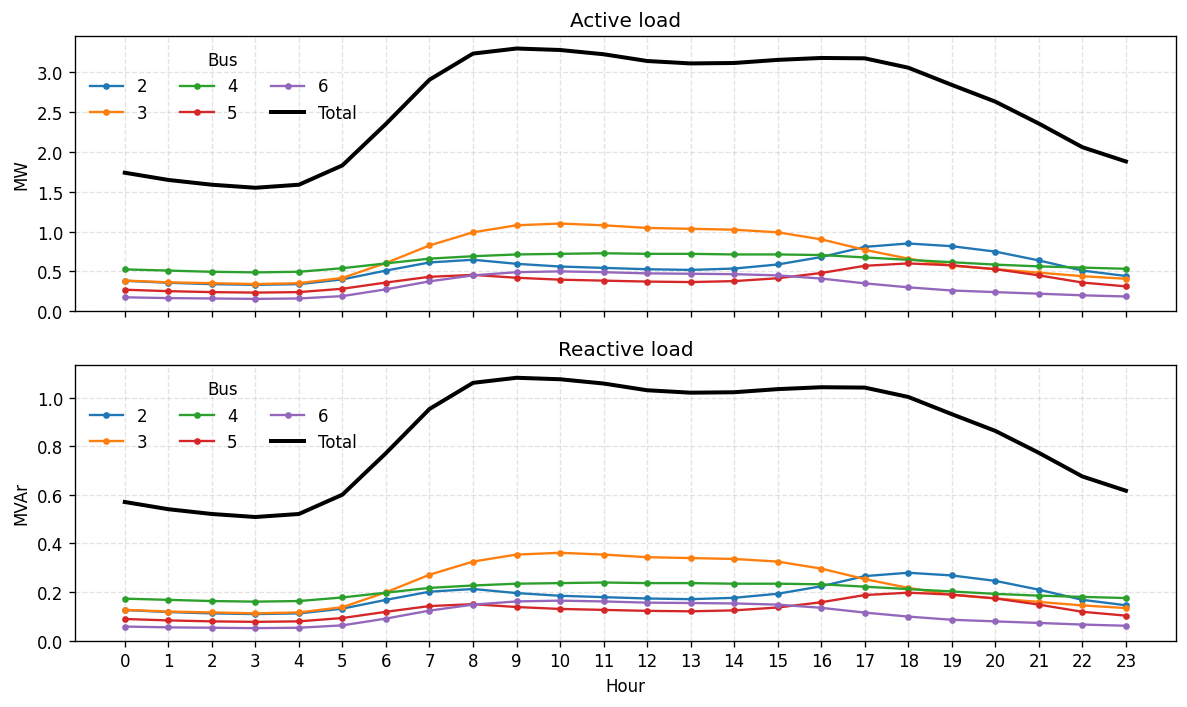

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp  # 导入 Gurobi Python 接口
from gurobipy import GRB  # 导入 Gurobi 常量，例如无穷大和变量类型

S_base = 10.0
V_min, V_max = 0.95, 1.05
hours = range(24)

bus_df = pd.DataFrame([(1, "slack"), (2, "PQ"), (3, "PQ"), (4, "PQ"), (5, "PQ"), (6, "PQ")], columns=["bus", "type"])
branch_df = pd.DataFrame(
    [("L12", 1, 2, 0.010, 0.030, 6.0), ("L23", 2, 3, 0.012, 0.025, 4.5),
     ("L34", 3, 4, 0.010, 0.020, 4.0), ("L45", 4, 5, 0.011, 0.022, 3.5),
     ("L56", 5, 6, 0.009, 0.018, 3.0)],
    columns=["branch", "from_bus", "to_bus", "r_pu", "x_pu", "s_max_mva"],
)
load_base_df = pd.DataFrame([(2, "res", 0.85), (3, "com", 1.10), (4, "ind", 0.75), (5, "res", 0.60), (6, "com", 0.50)], columns=["bus", "class", "p_base_mw"])
load_base_df["q_base_mvar"] = load_base_df["p_base_mw"] * np.tan(np.arccos(0.95))

profile = {
    "res": [0.45, 0.42, 0.40, 0.39, 0.40, 0.47, 0.60, 0.72, 0.76, 0.70, 0.66, 0.64, 0.62, 0.61, 0.63, 0.69, 0.80, 0.95, 1.00, 0.96, 0.88, 0.75, 0.60, 0.52],
    "com": [0.35, 0.33, 0.32, 0.31, 0.32, 0.38, 0.55, 0.75, 0.90, 0.98, 1.00, 0.98, 0.95, 0.94, 0.93, 0.90, 0.82, 0.70, 0.60, 0.52, 0.48, 0.44, 0.40, 0.37],
    "ind": [0.70, 0.68, 0.66, 0.65, 0.66, 0.72, 0.80, 0.88, 0.92, 0.95, 0.96, 0.97, 0.96, 0.96, 0.95, 0.95, 0.94, 0.90, 0.86, 0.82, 0.78, 0.75, 0.73, 0.71],
}
load_ts = pd.DataFrame(
    [(h, bus, p * profile[c][h], q * profile[c][h]) for _, bus, c, p, q in load_base_df.itertuples(name=None) for h in hours],
    columns=["hour", "bus", "p_mw", "q_mvar"],
)
p_load_mw = load_ts.pivot(index="hour", columns="bus", values="p_mw")
q_load_mvar = load_ts.pivot(index="hour", columns="bus", values="q_mvar")
total_load = load_ts.groupby("hour")[["p_mw", "q_mvar"]].sum()

pos = {i: (i, 0) for i in bus_df["bus"]}
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=120)
for br, f, t, *_ in branch_df.itertuples(index=False, name=None):
    ax.plot([pos[f][0], pos[t][0]], [0, 0], color="black", lw=2)
    ax.text((f + t) / 2, 0.08, br, ha="center", fontsize=9)
for b, kind in bus_df.itertuples(index=False, name=None):
    ax.scatter(*pos[b], s=600, color="#87ceeb" if kind == "slack" else "#ffd166", edgecolor="black", zorder=3)
    ax.text(*pos[b], str(b), ha="center", va="center", weight="bold")
ax.set_title("6-bus radial feeder")
ax.set_xlim(0.5, 6.5)
ax.set_ylim(-0.4, 0.3)
ax.axis("off")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=120, sharex=True)
p_load_mw.plot(ax=axes[0], marker="o", ms=3, lw=1.4)
q_load_mvar.plot(ax=axes[1], marker="o", ms=3, lw=1.4)
total_load["p_mw"].plot(ax=axes[0], color="black", lw=2.4, label="Total")
total_load["q_mvar"].plot(ax=axes[1], color="black", lw=2.4, label="Total")
axes[0].set_title("Active load")
axes[1].set_title("Reactive load")
axes[0].set_ylabel("MW")
axes[1].set_ylabel("MVAr")
axes[1].set_xlabel("Hour")
axes[1].set_xticks(list(hours))
for ax in axes:
    ax.grid(ls="--", alpha=0.35)
    ax.legend(title="Bus", ncol=3, frameon=False)
fig.tight_layout()
plt.show()


In [ ]:
buses = bus_df["bus"].tolist()  # 取出节点编号列表
branches = branch_df["branch"].tolist()  # 取出支路编号列表

In [3]:


buses = bus_df["bus"].tolist()  # 取出节点编号列表
branches = branch_df["branch"].tolist()  # 取出支路编号列表
parent = dict(zip(branch_df["to_bus"], branch_df["branch"]))  # 记录每个非根节点的上游支路
children = {b: branch_df.loc[branch_df["from_bus"] == b, "branch"].tolist() for b in buses}  # 记录每个节点的下游支路

grid_price = dict(zip(hours, [45]*7 + [70]*5 + [90]*5 + [120]*4 + [75]*3))  # 设置 24 小时购电电价
dg_cost, p_dg_max = 85.0, 0.8  # 设置 6 节点 DG 发电成本和最大有功出力
q_cap, q_grid_max, cap_cost = 0.35, 0.85, 2.0  # 设置 5 节点电容容量、主网无功上限和投切成本

env = gp.Env(empty=True)  # 创建 Gurobi 环境
env.setParam("OutputFlag", 0)  # 关闭 Gurobi 求解日志
env.start()  # 启动 Gurobi 环境
m = gp.Model("milp_opf_6bus", env=env)  # 创建 MILP 最优潮流模型

P = m.addVars(branches, hours, lb=-GRB.INFINITY, name="P")  # 定义支路有功潮流变量
Q = m.addVars(branches, hours, lb=-GRB.INFINITY, name="Q")  # 定义支路无功潮流变量
v = m.addVars(buses, hours, lb=V_min**2, ub=V_max**2, name="v")  # 定义节点电压平方变量
p_grid = m.addVars(hours, lb=0, ub=6.0, name="p_grid")  # 定义变电站有功购电变量
q_grid = m.addVars(hours, lb=0, ub=q_grid_max, name="q_grid")  # 定义变电站无功供给变量
p_dg = m.addVars(hours, lb=0, ub=p_dg_max, name="p_dg")  # 定义 6 节点 DG 有功出力变量
cap = m.addVars(hours, vtype=GRB.BINARY, name="cap")  # 定义 5 节点电容投切二进制变量

for h in hours:  # 按小时添加约束
    m.addConstr(v[1, h] == 1.0)  # 固定变电站节点电压为 1.0 pu 的平方
    m.addConstr(p_grid[h] == P["L12", h])  # 变电站有功等于首段支路有功潮流
    m.addConstr(q_grid[h] == Q["L12", h])  # 变电站无功等于首段支路无功潮流

    for br, f, t, r, x, smax in branch_df.itertuples(index=False, name=None):  # 遍历每条支路
        m.addConstr(v[t, h] == v[f, h] - 2 * (r * P[br, h] / S_base + x * Q[br, h] / S_base))  # 线性 DistFlow 电压降约束
        m.addConstr(P[br, h] <= smax)  # 支路有功上限
        m.addConstr(P[br, h] >= -smax)  # 支路有功下限
        m.addConstr(Q[br, h] <= smax)  # 支路无功上限
        m.addConstr(Q[br, h] >= -smax)  # 支路无功下限

    for b in buses[1:]:  # 遍历所有非变电站节点
        out_p = gp.quicksum(P[br, h] for br in children[b])  # 计算节点流向下游的有功
        out_q = gp.quicksum(Q[br, h] for br in children[b])  # 计算节点流向下游的无功
        p_gen = p_dg[h] if b == 6 else 0  # 仅在 6 节点接入 DG 有功出力
        q_inj = q_cap * cap[h] if b == 5 else 0  # 仅在 5 节点接入可投切电容无功
        m.addConstr(P[parent[b], h] == p_load_mw.loc[h, b] - p_gen + out_p)  # 节点有功功率平衡
        m.addConstr(Q[parent[b], h] == q_load_mvar.loc[h, b] - q_inj + out_q)  # 节点无功功率平衡

m.setObjective(gp.quicksum(grid_price[h] * p_grid[h] + dg_cost * p_dg[h] + cap_cost * cap[h] for h in hours), GRB.MINIMIZE)  # 最小化购电、DG 和电容投切总成本
m.optimize()  # 调用 Gurobi 求解 MILP

opf = pd.DataFrame({  # 汇总每小时调度结果
    "p_grid_mw": [p_grid[h].X for h in hours],  # 记录变电站有功购电
    "p_dg_mw": [p_dg[h].X for h in hours],  # 记录 DG 有功出力
    "q_grid_mvar": [q_grid[h].X for h in hours],  # 记录变电站无功供给
    "cap_on": [cap[h].X for h in hours],  # 记录电容投切状态
    "v_min_pu": [min(v[b, h].X**0.5 for b in buses) for h in hours],  # 记录每小时最低节点电压
}, index=list(hours))  # 用小时作为结果表索引
v_pu = pd.DataFrame({b: [v[b, h].X**0.5 for h in hours] for b in buses}, index=list(hours))  # 汇总所有节点电压幅值




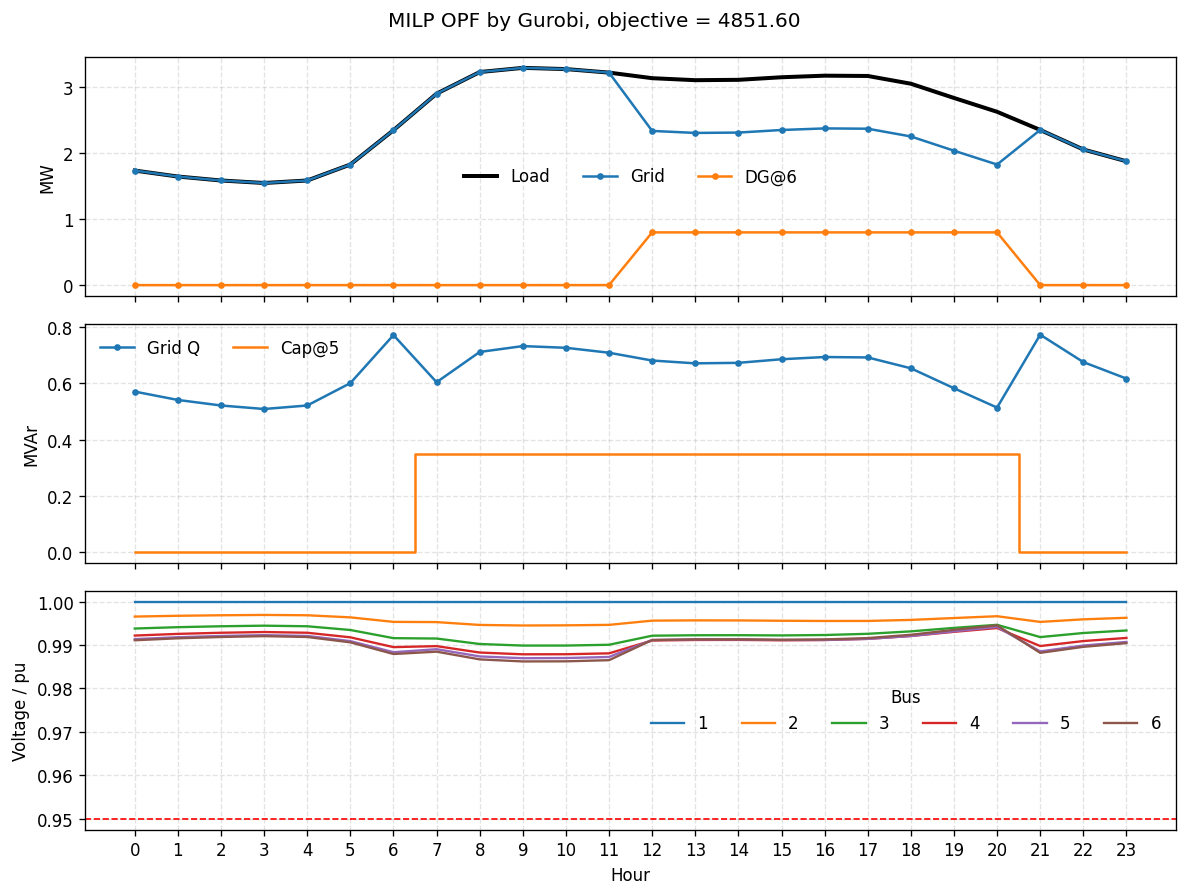

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), dpi=120, sharex=True)  # 创建三行结果图
axes[0].plot(hours, total_load["p_mw"], color="black", lw=2.4, label="Load")  # 绘制系统总有功负荷
axes[0].plot(hours, opf["p_grid_mw"], marker="o", ms=3, label="Grid")  # 绘制变电站有功出力
axes[0].plot(hours, opf["p_dg_mw"], marker="o", ms=3, label="DG@6")  # 绘制 DG 有功出力
axes[0].set_ylabel("MW")  # 设置第一张子图纵轴单位
axes[0].legend(frameon=False, ncol=3)  # 显示第一张子图图例

axes[1].plot(hours, opf["q_grid_mvar"], marker="o", ms=3, label="Grid Q")  # 绘制变电站无功供给
axes[1].step(hours, q_cap * opf["cap_on"], where="mid", label="Cap@5")  # 绘制电容器无功投入量
axes[1].set_ylabel("MVAr")  # 设置第二张子图纵轴单位
axes[1].legend(frameon=False, ncol=2)  # 显示第二张子图图例

v_pu.plot(ax=axes[2], lw=1.4)  # 绘制所有节点电压曲线
axes[2].axhline(V_min, color="red", ls="--", lw=1)  # 绘制电压下限参考线
axes[2].set_ylabel("Voltage / pu")  # 设置第三张子图纵轴单位
axes[2].set_xlabel("Hour")  # 设置横轴为小时
axes[2].set_xticks(list(hours))  # 设置 24 小时刻度
axes[2].legend(title="Bus", ncol=6, frameon=False)  # 显示节点电压图例

for ax in axes:  # 遍历三张子图
    ax.grid(ls="--", alpha=0.35)  # 添加网格线
fig.suptitle(f"MILP OPF by Gurobi, objective = {m.ObjVal:.2f}", y=0.99)  # 设置总标题并显示目标函数值
fig.tight_layout()  # 自动调整图形布局
plt.show()  # 显示调度结果图